<a href="https://colab.research.google.com/github/fauziah-azzhr/PertemuanTigaBelas/blob/main/TugasKlasifikasiTradisional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mengambil dataset Fashion-MNIST...
Jumlah data : (1000, 784)
Jumlah label: (1000,)


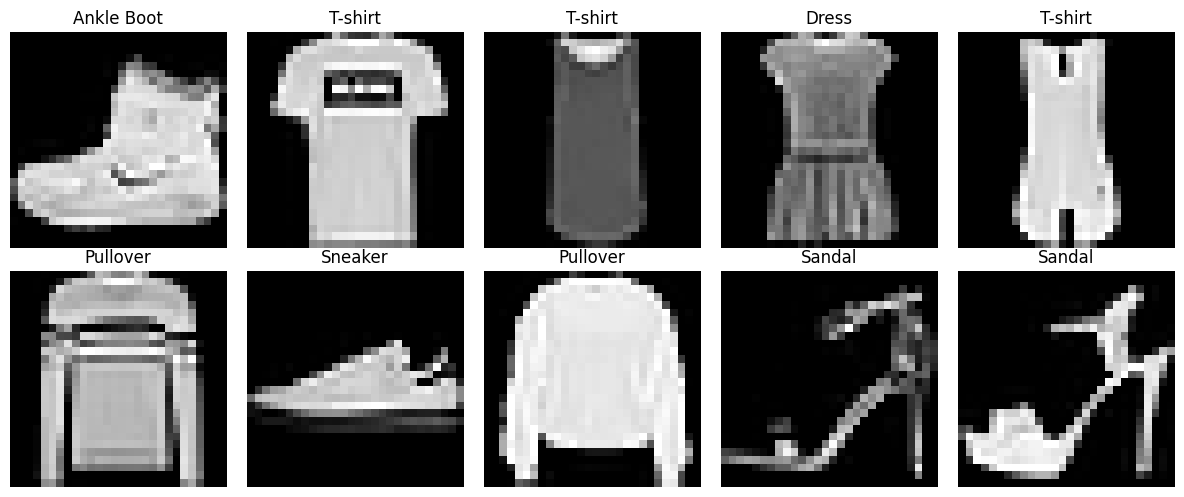

Ekstraksi fitur dimulai...
HOG Feature Shape      : (1000, 1296)
Texture Feature Shape  : (1000, 14)
Total Feature Shape: (1000, 1310)

IMPLEMENTASI KNN

KNN -> k=1, metric=euclidean

KNN -> k=3, metric=euclidean

KNN -> k=5, metric=euclidean

KNN -> k=7, metric=euclidean

KNN -> k=9, metric=euclidean

KNN -> k=11, metric=euclidean

KNN -> k=1, metric=manhattan

KNN -> k=3, metric=manhattan

KNN -> k=5, metric=manhattan

KNN -> k=7, metric=manhattan

KNN -> k=9, metric=manhattan

KNN -> k=11, metric=manhattan

KNN -> k=1, metric=minkowski

KNN -> k=3, metric=minkowski

KNN -> k=5, metric=minkowski

KNN -> k=7, metric=minkowski

KNN -> k=9, metric=minkowski

KNN -> k=11, metric=minkowski

HASIL KNN:
     k     Metric  Accuracy  Precision  Recall  F1-Score  Training Time  \
0    1  euclidean     0.820   0.828874   0.820  0.821323       0.001738   
1    3  euclidean     0.810   0.810504   0.810  0.802201       0.001625   
2    5  euclidean     0.820   0.834745   0.820  0.817331       0.00

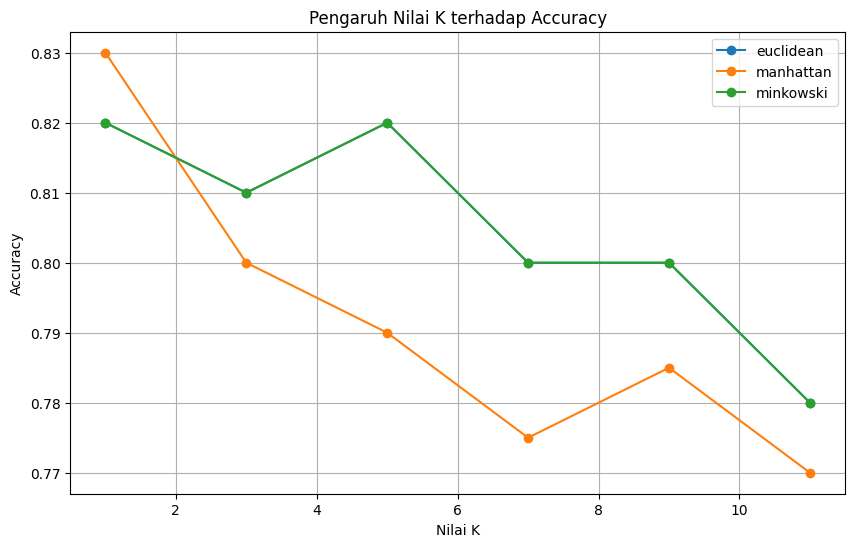


ANALISIS KNN:
- k kecil (1) cenderung overfitting
- k besar cenderung underfitting
- Nilai tengah biasanya paling optimal

IMPLEMENTASI SVM

SVM -> kernel=linear, C=0.1

SVM -> kernel=linear, C=1

SVM -> kernel=linear, C=10

SVM -> kernel=linear, C=100

SVM -> kernel=poly, C=0.1

SVM -> kernel=poly, C=1

SVM -> kernel=poly, C=10

SVM -> kernel=poly, C=100

SVM -> kernel=rbf, C=0.1, gamma=0.001

SVM -> kernel=rbf, C=0.1, gamma=0.01

SVM -> kernel=rbf, C=0.1, gamma=0.1

SVM -> kernel=rbf, C=0.1, gamma=1

SVM -> kernel=rbf, C=1, gamma=0.001

SVM -> kernel=rbf, C=1, gamma=0.01

SVM -> kernel=rbf, C=1, gamma=0.1

SVM -> kernel=rbf, C=1, gamma=1

SVM -> kernel=rbf, C=10, gamma=0.001

SVM -> kernel=rbf, C=10, gamma=0.01

SVM -> kernel=rbf, C=10, gamma=0.1

SVM -> kernel=rbf, C=10, gamma=1

SVM -> kernel=rbf, C=100, gamma=0.001

SVM -> kernel=rbf, C=100, gamma=0.01

SVM -> kernel=rbf, C=100, gamma=0.1

SVM -> kernel=rbf, C=100, gamma=1

HASIL SVM:
    Kernel      C  Gamma  Accuracy  Precision

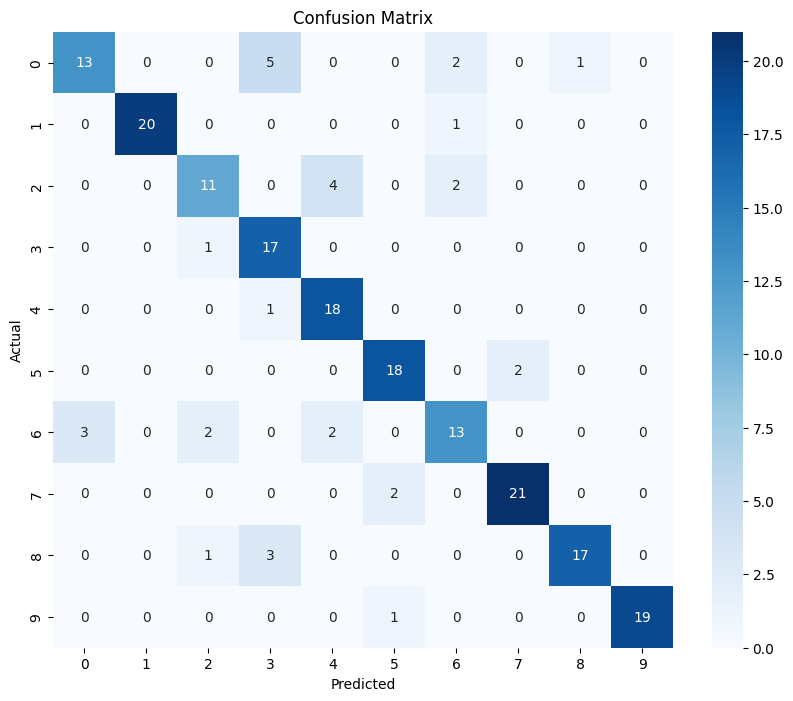


CLASSIFICATION REPORT:
              precision    recall  f1-score   support

     T-shirt       0.81      0.62      0.70        21
     Trouser       1.00      0.95      0.98        21
    Pullover       0.73      0.65      0.69        17
       Dress       0.65      0.94      0.77        18
        Coat       0.75      0.95      0.84        19
      Sandal       0.86      0.90      0.88        20
       Shirt       0.72      0.65      0.68        20
     Sneaker       0.91      0.91      0.91        23
         Bag       0.94      0.81      0.87        21
  Ankle Boot       1.00      0.95      0.97        20

    accuracy                           0.83       200
   macro avg       0.84      0.83      0.83       200
weighted avg       0.84      0.83      0.83       200


Membuat ROC Curve...


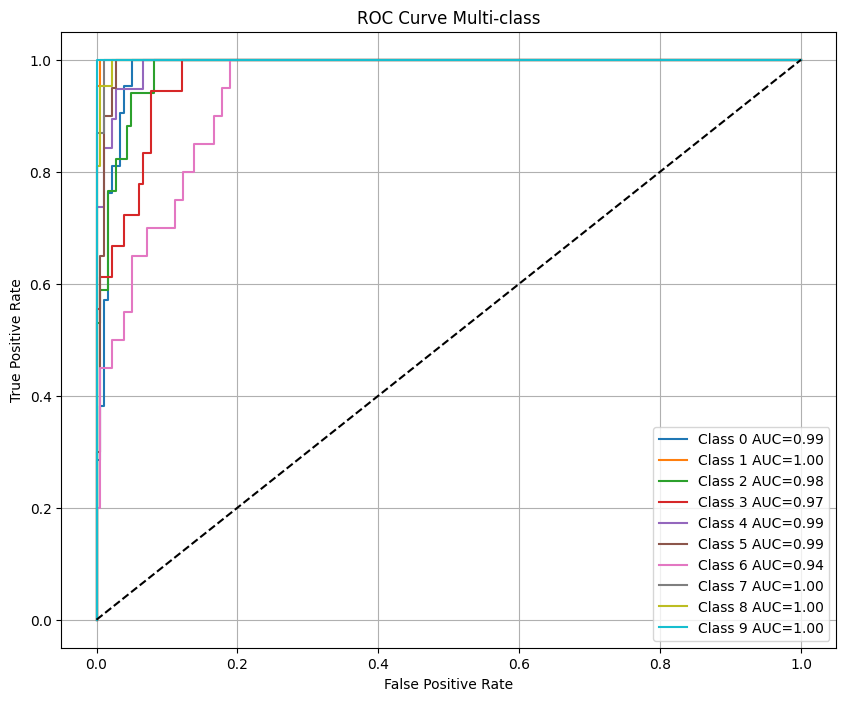


CROSS VALIDATION

BEST PARAMETER:
{'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}

BEST SCORE:
0.8300000000000001


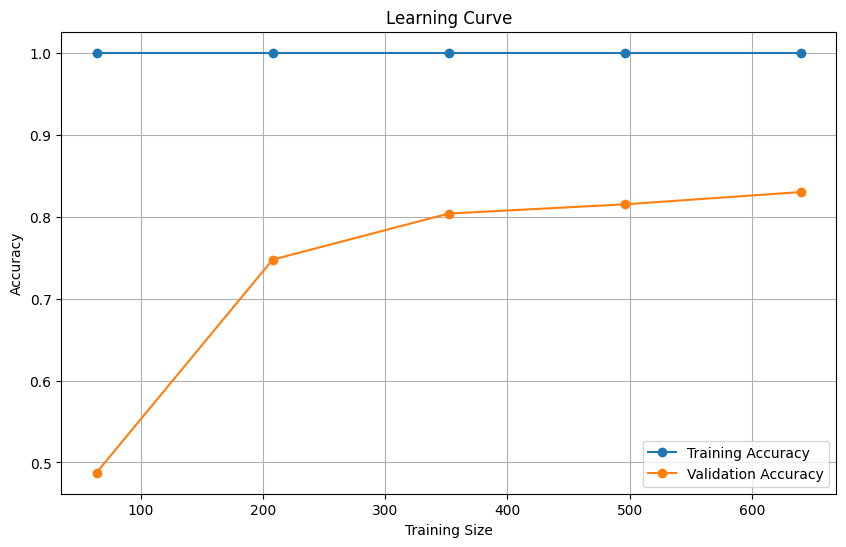


Visualisasi Decision Boundary PCA 2D...


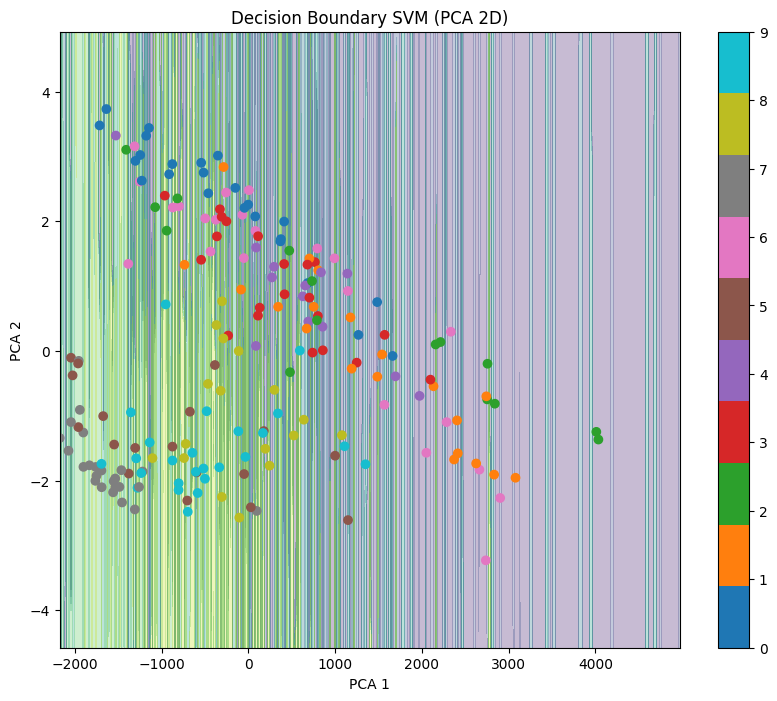


KESIMPULAN

1. Metode terbaik:
SVM memberikan performa terbaik

2. Parameter optimal KNN:
k                         1
Metric            manhattan
Accuracy               0.83
Precision          0.834606
Recall                 0.83
F1-Score           0.828487
Training Time       0.00155
Inference Time     0.429877
Name: 6, dtype: object

3. Parameter optimal SVM:
Kernel                poly
C                     10.0
Gamma                    -
Accuracy             0.835
Precision         0.844845
Recall               0.835
F1-Score          0.833941
Training Time      2.31983
Inference Time    0.074831
Name: 6, dtype: object

4. Trade-off:
- KNN cepat training namun lambat inference
- SVM lebih kompleks namun akurasi lebih tinggi
- Kernel RBF biasanya paling baik untuk data kompleks

5. Rekomendasi:
Gunakan SVM RBF untuk klasifikasi citra Fashion-MNIST
karena memiliki akurasi tinggi dan generalisasi baik.


In [2]:
# =========================================================
# 1. IMPORT LIBRARY
# =========================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.datasets import fetch_openml
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    learning_curve
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.multiclass import OneVsRestClassifier

from skimage.feature import hog, local_binary_pattern, graycomatrix, graycoprops

import warnings
warnings.filterwarnings('ignore')

# =========================================================
# 2. LOAD DATASET FASHION-MNIST
# =========================================================
print("Mengambil dataset Fashion-MNIST...")

fashion = fetch_openml('Fashion-MNIST', version=1, as_frame=False)

X = fashion.data
y = fashion.target.astype(int)

# Ambil 1000 sampel saja
X = X[:1000]
y = y[:1000]

print("Jumlah data :", X.shape)
print("Jumlah label:", y.shape)

# =========================================================
# 3. VISUALISASI DATA
# =========================================================
class_names = [
    "T-shirt", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle Boot"
]

plt.figure(figsize=(12,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X[i].reshape(28,28), cmap='gray')
    plt.title(class_names[y[i]])
    plt.axis('off')

plt.tight_layout()
plt.show()

# =========================================================
# 4. EKSTRAKSI FITUR
# Minimal 2 fitur:
# - HOG
# - LBP + GLCM
# =========================================================

print("Ekstraksi fitur dimulai...")

hog_features = []
texture_features = []

for img in X:

    image = img.reshape(28,28).astype('uint8')

    # =====================================================
    # HOG FEATURE
    # =====================================================
    hog_feat = hog(
        image,
        orientations=9,
        pixels_per_cell=(4,4),
        cells_per_block=(2,2),
        visualize=False
    )

    hog_features.append(hog_feat)

    # =====================================================
    # TEXTURE FEATURE (LBP + GLCM)
    # =====================================================

    # LBP
    lbp = local_binary_pattern(image, P=8, R=1, method='uniform')
    lbp_hist, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0,11),
        range=(0,10)
    )

    lbp_hist = lbp_hist.astype("float")
    lbp_hist /= (lbp_hist.sum() + 1e-6)

    # GLCM
    glcm = graycomatrix(
        image,
        distances=[1],
        angles=[0],
        levels=256,
        symmetric=True,
        normed=True
    )

    contrast = graycoprops(glcm, 'contrast')[0,0]
    correlation = graycoprops(glcm, 'correlation')[0,0]
    energy = graycoprops(glcm, 'energy')[0,0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0,0]

    texture_feat = np.hstack([
        lbp_hist,
        contrast,
        correlation,
        energy,
        homogeneity
    ])

    texture_features.append(texture_feat)

hog_features = np.array(hog_features)
texture_features = np.array(texture_features)

print("HOG Feature Shape      :", hog_features.shape)
print("Texture Feature Shape  :", texture_features.shape)

# =========================================================
# GABUNGKAN FITUR
# =========================================================
X_features = np.hstack([hog_features, texture_features])

print("Total Feature Shape:", X_features.shape)

# =========================================================
# 5. SPLIT DATA
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_features,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# =========================================================
# NORMALISASI
# =========================================================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================================================
# 6. IMPLEMENTASI KNN
# =========================================================
print("\n==============================")
print("IMPLEMENTASI KNN")
print("==============================")

k_values = [1,3,5,7,9,11]
distance_metrics = ['euclidean', 'manhattan', 'minkowski']

knn_results = []

for metric in distance_metrics:

    for k in k_values:

        print(f"\nKNN -> k={k}, metric={metric}")

        start_train = time.time()

        knn = KNeighborsClassifier(
            n_neighbors=k,
            metric=metric
        )

        knn.fit(X_train, y_train)

        end_train = time.time()

        train_time = end_train - start_train

        # Inference
        start_infer = time.time()
        y_pred = knn.predict(X_test)
        end_infer = time.time()

        inference_time = end_infer - start_infer

        # Evaluasi
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='weighted')
        rec = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')

        knn_results.append([
            k,
            metric,
            acc,
            prec,
            rec,
            f1,
            train_time,
            inference_time
        ])

# =========================================================
# HASIL KNN
# =========================================================
knn_df = pd.DataFrame(knn_results, columns=[
    'k',
    'Metric',
    'Accuracy',
    'Precision',
    'Recall',
    'F1-Score',
    'Training Time',
    'Inference Time'
])

print("\nHASIL KNN:")
print(knn_df)

# =========================================================
# VISUALISASI PENGARUH NILAI K
# =========================================================
plt.figure(figsize=(10,6))

for metric in distance_metrics:

    subset = knn_df[knn_df['Metric']==metric]

    plt.plot(
        subset['k'],
        subset['Accuracy'],
        marker='o',
        label=metric
    )

plt.title("Pengaruh Nilai K terhadap Accuracy")
plt.xlabel("Nilai K")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

# =========================================================
# ANALISIS OVERFITTING / UNDERFITTING
# =========================================================
print("\nANALISIS KNN:")
print("- k kecil (1) cenderung overfitting")
print("- k besar cenderung underfitting")
print("- Nilai tengah biasanya paling optimal")

# =========================================================
# 7. IMPLEMENTASI SVM
# =========================================================
print("\n==============================")
print("IMPLEMENTASI SVM")
print("==============================")

svm_results = []

kernels = ['linear', 'poly', 'rbf']
C_values = [0.1, 1, 10, 100]
gamma_values = [0.001, 0.01, 0.1, 1]

for kernel in kernels:

    if kernel == 'rbf':

        for C in C_values:
            for gamma in gamma_values:

                print(f"\nSVM -> kernel={kernel}, C={C}, gamma={gamma}")

                start_train = time.time()

                svm = SVC(
                    kernel=kernel,
                    C=C,
                    gamma=gamma,
                    probability=True
                )

                svm.fit(X_train, y_train)

                end_train = time.time()

                train_time = end_train - start_train

                start_infer = time.time()
                y_pred = svm.predict(X_test)
                end_infer = time.time()

                inference_time = end_infer - start_infer

                acc = accuracy_score(y_test, y_pred)
                prec = precision_score(y_test, y_pred, average='weighted')
                rec = recall_score(y_test, y_pred, average='weighted')
                f1 = f1_score(y_test, y_pred, average='weighted')

                svm_results.append([
                    kernel,
                    C,
                    gamma,
                    acc,
                    prec,
                    rec,
                    f1,
                    train_time,
                    inference_time
                ])

    else:

        for C in C_values:

            print(f"\nSVM -> kernel={kernel}, C={C}")

            start_train = time.time()

            svm = SVC(
                kernel=kernel,
                C=C,
                probability=True
            )

            svm.fit(X_train, y_train)

            end_train = time.time()

            train_time = end_train - start_train

            start_infer = time.time()
            y_pred = svm.predict(X_test)
            end_infer = time.time()

            inference_time = end_infer - start_infer

            acc = accuracy_score(y_test, y_pred)
            prec = precision_score(y_test, y_pred, average='weighted')
            rec = recall_score(y_test, y_pred, average='weighted')
            f1 = f1_score(y_test, y_pred, average='weighted')

            svm_results.append([
                kernel,
                C,
                '-',
                acc,
                prec,
                rec,
                f1,
                train_time,
                inference_time
            ])

# =========================================================
# HASIL SVM
# =========================================================
svm_df = pd.DataFrame(svm_results, columns=[
    'Kernel',
    'C',
    'Gamma',
    'Accuracy',
    'Precision',
    'Recall',
    'F1-Score',
    'Training Time',
    'Inference Time'
])

print("\nHASIL SVM:")
print(svm_df)

# =========================================================
# 8. CONFUSION MATRIX MODEL TERBAIK
# =========================================================
best_svm = svm_df.sort_values(by='Accuracy', ascending=False).iloc[0]

print("\nMODEL TERBAIK:")
print(best_svm)

# Train ulang model terbaik
if best_svm['Kernel'] == 'rbf':

    best_model = SVC(
        kernel='rbf',
        C=best_svm['C'],
        gamma=best_svm['Gamma'],
        probability=True
    )

else:

    best_model = SVC(
        kernel=best_svm['Kernel'],
        C=best_svm['C'],
        probability=True
    )

best_model.fit(X_train, y_train)

y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================================================
# CLASSIFICATION REPORT
# =========================================================
print("\nCLASSIFICATION REPORT:")
print(classification_report(
    y_test,
    y_pred_best,
    target_names=class_names
))

# =========================================================
# 9. ROC CURVE & AUC
# =========================================================
print("\nMembuat ROC Curve...")

y_test_bin = label_binarize(y_test, classes=np.unique(y))
n_classes = y_test_bin.shape[1]

classifier = OneVsRestClassifier(best_model)
y_score = classifier.fit(X_train, y_train).decision_function(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):

    fpr[i], tpr[i], _ = roc_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )

    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10,8))

for i in range(n_classes):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f'Class {i} AUC={roc_auc[i]:.2f}'
    )

plt.plot([0,1],[0,1],'k--')

plt.title("ROC Curve Multi-class")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()

# =========================================================
# 10. CROSS VALIDATION
# =========================================================
print("\n==============================")
print("CROSS VALIDATION")
print("==============================")

cv = StratifiedKFold(n_splits=5)

grid_params = {
    'C':[0.1,1,10],
    'kernel':['linear','rbf'],
    'gamma':['scale',0.01,0.001]
}

grid = GridSearchCV(
    SVC(),
    grid_params,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("\nBEST PARAMETER:")
print(grid.best_params_)

print("\nBEST SCORE:")
print(grid.best_score_)

# =========================================================
# 11. LEARNING CURVE
# =========================================================
train_sizes, train_scores, test_scores = learning_curve(
    grid.best_estimator_,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1,1.0,5)
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(10,6))

plt.plot(train_sizes, train_mean, marker='o', label='Training Accuracy')
plt.plot(train_sizes, test_mean, marker='o', label='Validation Accuracy')

plt.title("Learning Curve")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

# =========================================================
# 12. VISUALISASI PCA 2D
# =========================================================
print("\nVisualisasi Decision Boundary PCA 2D...")

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_features)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42
)

svm_vis = SVC(kernel='rbf', C=10, gamma=0.01)

svm_vis.fit(X_train_pca, y_train_pca)

# meshgrid
x_min, x_max = X_pca[:,0].min()-1, X_pca[:,0].max()+1
y_min, y_max = X_pca[:,1].min()-1, X_pca[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.5),
    np.arange(y_min, y_max, 0.5)
)

Z = svm_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10,8))

plt.contourf(xx, yy, Z, alpha=0.3)

scatter = plt.scatter(
    X_test_pca[:,0],
    X_test_pca[:,1],
    c=y_test_pca,
    cmap='tab10'
)

plt.title("Decision Boundary SVM (PCA 2D)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(scatter)
plt.show()

# =========================================================
# 13. KESIMPULAN OTOMATIS
# =========================================================
print("\n==============================")
print("KESIMPULAN")
print("==============================")

best_knn = knn_df.sort_values(by='Accuracy', ascending=False).iloc[0]

print("\n1. Metode terbaik:")
if best_svm['Accuracy'] > best_knn['Accuracy']:
    print("SVM memberikan performa terbaik")
else:
    print("KNN memberikan performa terbaik")

print("\n2. Parameter optimal KNN:")
print(best_knn)

print("\n3. Parameter optimal SVM:")
print(best_svm)

print("\n4. Trade-off:")
print("- KNN cepat training namun lambat inference")
print("- SVM lebih kompleks namun akurasi lebih tinggi")
print("- Kernel RBF biasanya paling baik untuk data kompleks")

print("\n5. Rekomendasi:")
print("Gunakan SVM RBF untuk klasifikasi citra Fashion-MNIST")
print("karena memiliki akurasi tinggi dan generalisasi baik.")